# 📊 Notebook 3 — Exploratory Data Analysis (Business EDA)
**Project:** Shopify E-Commerce Analytics Data Warehouse  
**Layer:** Analytics — Business Insights  
**Purpose:** Revenue & profit trends, category/country/channel performance, discount vs profit, returns analysis.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d2e',
    'axes.edgecolor':'#2e3250','axes.labelcolor':'#c9d1d9',
    'xtick.color':'#8b949e','ytick.color':'#8b949e',
    'text.color':'#c9d1d9','grid.color':'#2e3250',
    'grid.linestyle':'--','grid.alpha':0.5,
    'font.family':'monospace','axes.titlesize':13,'axes.titleweight':'bold',
})
ACCENT,ACCENT2,ACCENT3,RED,YELLOW = '#4fc3f7','#a78bfa','#34d399','#f87171','#fbbf24'
PALETTE = [ACCENT, ACCENT2, ACCENT3, RED, YELLOW, '#fb923c', '#e879f9']

# ── Load warehouse ─────────────────────────────────────────────────
fact = pd.read_csv('warehouse/fact_sales.csv')  # No need for parse_dates
dprod = pd.read_csv('warehouse/dim_product.csv')
dcust = pd.read_csv('warehouse/dim_customer.csv')
dcoun = pd.read_csv('warehouse/dim_country.csv')
dts = pd.read_csv('warehouse/dim_traffic_source.csv')
dpm = pd.read_csv('warehouse/dim_payment_method.csv')
ddate = pd.read_csv('warehouse/dim_date.csv')

# Ensure date_key is int type for merging
fact['date_key'] = fact['date_key'].astype(int)
ddate['date_key'] = ddate['date_key'].astype(int)

# Enrich fact with dimensions
fact = fact.merge(ddate[['date_key','year','month','month_label','quarter_label']], on='date_key')
fact = fact.merge(dprod[['product_key','product_category']], on='product_key')
fact = fact.merge(dcoun[['country_key','country_name','region']], on='country_key')
fact = fact.merge(dts[['traffic_source_key','traffic_source','channel_type']], on='traffic_source_key')
fact = fact.merge(dpm[['payment_method_key','payment_method']], on='payment_method_key')

print(f"✅ Enriched fact table: {fact.shape[0]:,} rows")
print(f"📊 Date range: {fact['date_key'].min()} → {fact['date_key'].max()}")
print(f"💰 Total revenue: ${fact['revenue'].sum():,.2f}")

✅ Enriched fact table: 314,418 rows
📊 Date range: 20230101 → 20250618
💰 Total revenue: $312,228,580.29


## 1. Revenue Trend Analysis

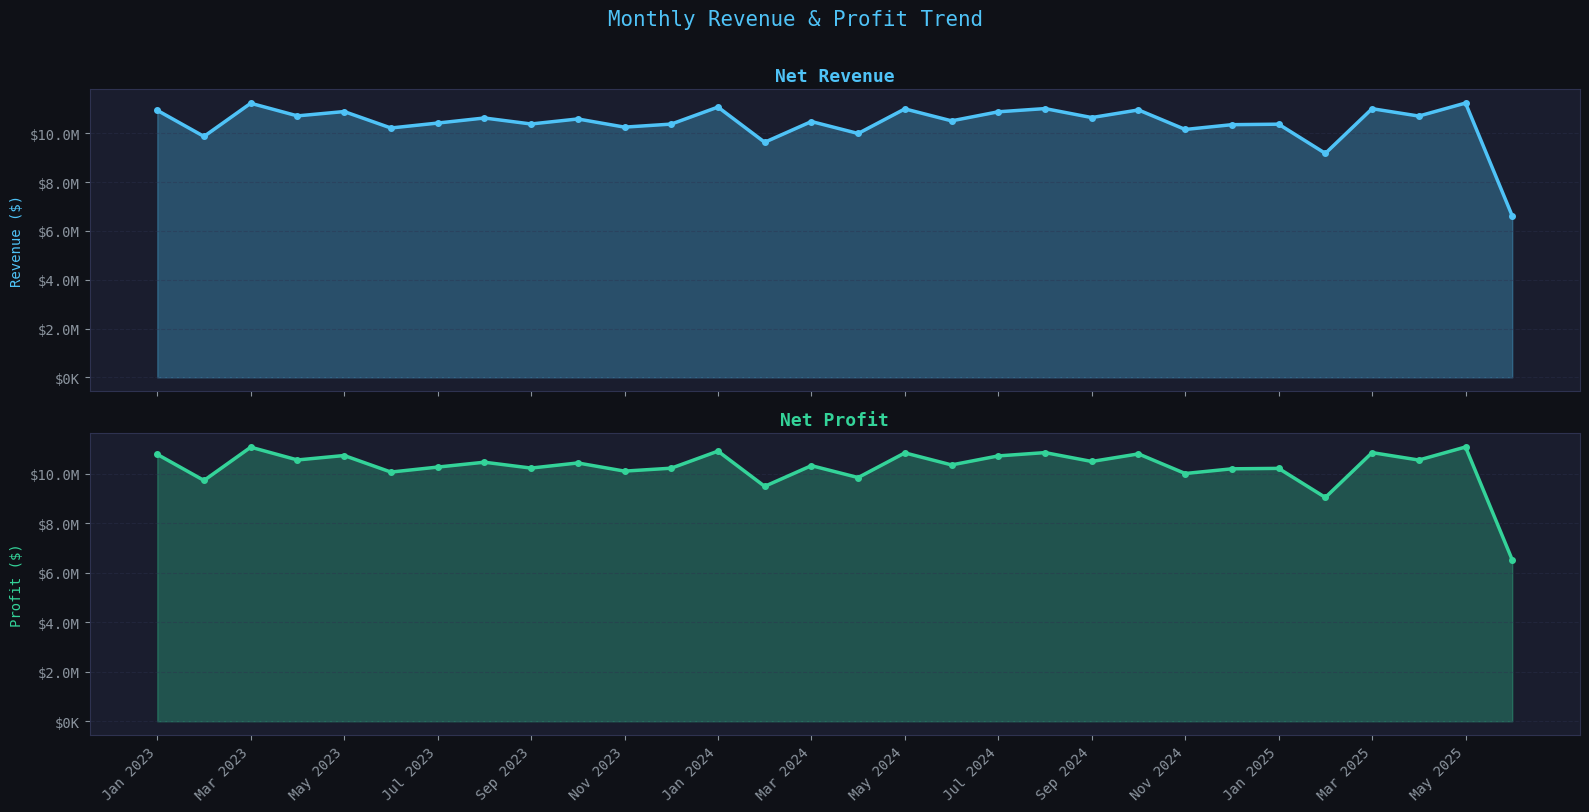


📌 INSIGHT: Revenue and profit move in tandem — no systematic margin compression over time.
📌 BUSINESS INTERPRETATION: Healthy scaling; discounts are not eroding profit proportionally.
📌 RECOMMENDATION: Identify peak months and pre-load inventory accordingly to avoid stockouts.


In [4]:
monthly = fact.groupby(['year','month','month_label']).agg(
    revenue=('revenue','sum'), profit=('profit','sum'),
    orders=('order_id','nunique')
).reset_index().sort_values(['year','month'])

fig, axes = plt.subplots(2,1, figsize=(16,8), sharex=True)
fig.suptitle("Monthly Revenue & Profit Trend", fontsize=15, color=ACCENT, y=1.01)

ax1, ax2 = axes
labels = monthly['month_label']
x = range(len(labels))

ax1.fill_between(x, monthly['revenue'], alpha=0.3, color=ACCENT)
ax1.plot(x, monthly['revenue'], color=ACCENT, linewidth=2.5, marker='o', markersize=4)
ax1.set_ylabel("Revenue ($)", color=ACCENT)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M' if v>=1e6 else f'${v/1e3:.0f}K'))
ax1.set_title("Net Revenue", color=ACCENT)

ax2.fill_between(x, monthly['profit'], alpha=0.3, color=ACCENT3)
ax2.plot(x, monthly['profit'], color=ACCENT3, linewidth=2.5, marker='o', markersize=4)
ax2.set_ylabel("Profit ($)", color=ACCENT3)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M' if v>=1e6 else f'${v/1e3:.0f}K'))
ax2.set_title("Net Profit", color=ACCENT3)

# Set x labels every 3 months
step = max(1, len(labels)//12)
ax2.set_xticks(list(range(0, len(labels), step)))
ax2.set_xticklabels([labels.iloc[i] for i in range(0, len(labels), step)], rotation=45, ha='right')

for ax in axes: ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT: Revenue and profit move in tandem — no systematic margin compression over time.")
print("📌 BUSINESS INTERPRETATION: Healthy scaling; discounts are not eroding profit proportionally.")
print("📌 RECOMMENDATION: Identify peak months and pre-load inventory accordingly to avoid stockouts.")

## 2. Category Performance

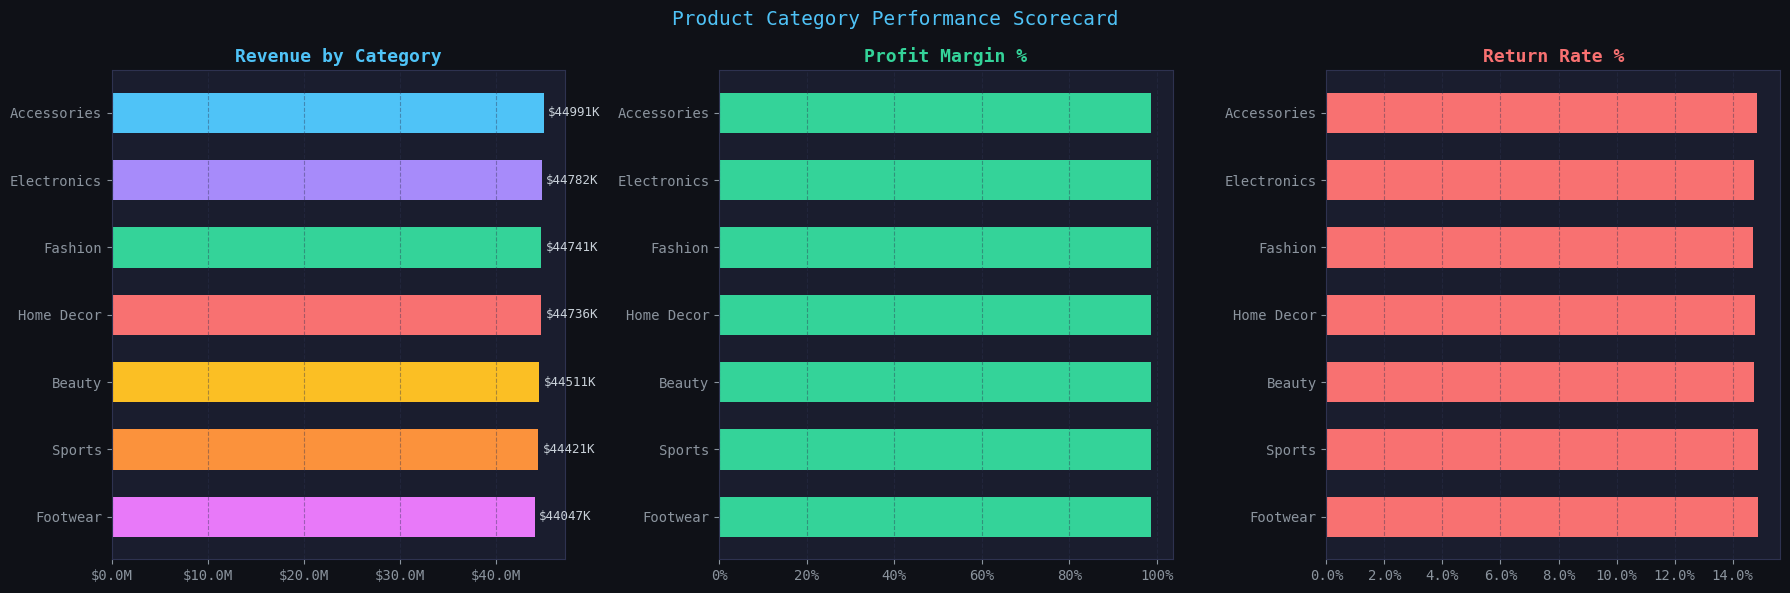


📌 INSIGHT: Categories vary significantly in both margin and return rate.
📌 BUSINESS INTERPRETATION: High-return categories may have fit/quality issues.
📌 RECOMMENDATION: Investigate high-return categories for product description accuracy.


In [5]:
cat = fact.groupby('product_category').agg(
    revenue=('revenue','sum'), profit=('profit','sum'),
    orders=('order_id','nunique'), units=('quantity','sum'),
    avg_discount=('discount_percent','mean'), return_rate=('is_returned','mean')
).reset_index().sort_values('revenue', ascending=False)
cat['margin_pct'] = (cat['profit']/cat['revenue']*100).round(2)
cat['return_pct'] = (cat['return_rate']*100).round(2)

fig, axes = plt.subplots(1,3, figsize=(18,6))
fig.suptitle("Product Category Performance Scorecard", fontsize=14, color=ACCENT)

# Revenue bars
bars = axes[0].barh(cat['product_category'], cat['revenue'],
                    color=PALETTE[:len(cat)], edgecolor='none', height=0.6)
axes[0].set_title("Revenue by Category", color=ACCENT)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
for bar, val in zip(bars, cat['revenue']):
    axes[0].text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                 f'${val/1e3:.0f}K', va='center', fontsize=9)

# Margin
bars2 = axes[1].barh(cat['product_category'], cat['margin_pct'],
                     color=ACCENT3, edgecolor='none', height=0.6)
axes[1].set_title("Profit Margin %", color=ACCENT3)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))

# Return rate
bars3 = axes[2].barh(cat['product_category'], cat['return_pct'],
                     color=RED, edgecolor='none', height=0.6)
axes[2].set_title("Return Rate %", color=RED)
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}%'))

for ax in axes:
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT: Categories vary significantly in both margin and return rate.")
print("📌 BUSINESS INTERPRETATION: High-return categories may have fit/quality issues.")
print("📌 RECOMMENDATION: Investigate high-return categories for product description accuracy.")

## 3. Country Performance

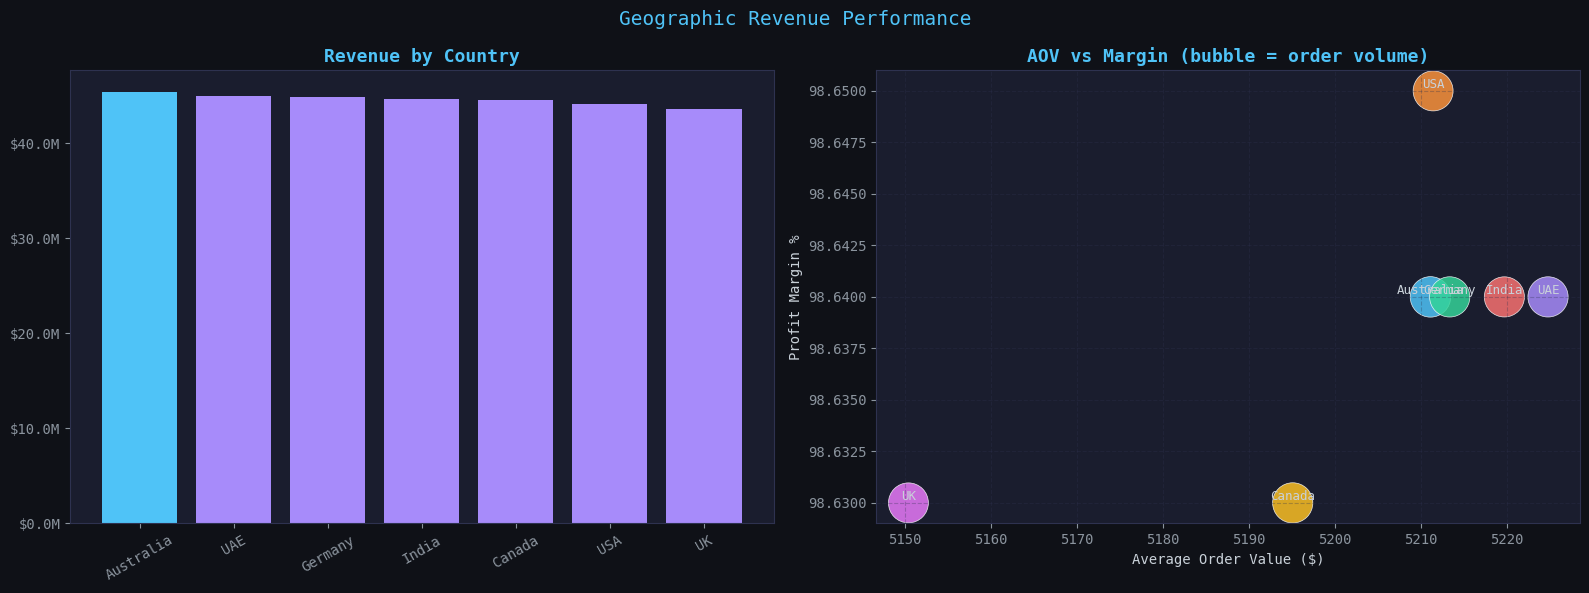


📌 INSIGHT: Some markets show higher AOV but similar or lower margin — shipping cost drag.
📌 RECOMMENDATION: Review shipping cost structure for low-margin high-AOV markets.


In [6]:
country = fact.groupby(['country_name','region']).agg(
    revenue=('revenue','sum'), profit=('profit','sum'),
    orders=('order_id','nunique'), customers=('customer_key','nunique')
).reset_index().sort_values('revenue', ascending=False)
country['aov']        = (country['revenue']/country['orders']).round(2)
country['margin_pct'] = (country['profit']/country['revenue']*100).round(2)

fig, axes = plt.subplots(1,2, figsize=(16,6))
fig.suptitle("Geographic Revenue Performance", fontsize=14, color=ACCENT)

colors = [ACCENT if r == country['revenue'].max() else ACCENT2 for r in country['revenue']]
axes[0].bar(country['country_name'], country['revenue'], color=colors, edgecolor='none')
axes[0].set_title("Revenue by Country", color=ACCENT)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)

scatter = axes[1].scatter(country['aov'], country['margin_pct'],
                          s=country['orders']/country['orders'].max()*800+50,
                          c=PALETTE[:len(country)], alpha=0.85, edgecolors='white', linewidths=0.5)
for _, row in country.iterrows():
    axes[1].annotate(row['country_name'], (row['aov'], row['margin_pct']),
                     fontsize=9, ha='center', va='bottom', color='#c9d1d9')
axes[1].set_xlabel("Average Order Value ($)")
axes[1].set_ylabel("Profit Margin %")
axes[1].set_title("AOV vs Margin (bubble = order volume)", color=ACCENT)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\n📌 INSIGHT: Some markets show higher AOV but similar or lower margin — shipping cost drag.")
print("📌 RECOMMENDATION: Review shipping cost structure for low-margin high-AOV markets.")

## 4. Traffic Source Analysis

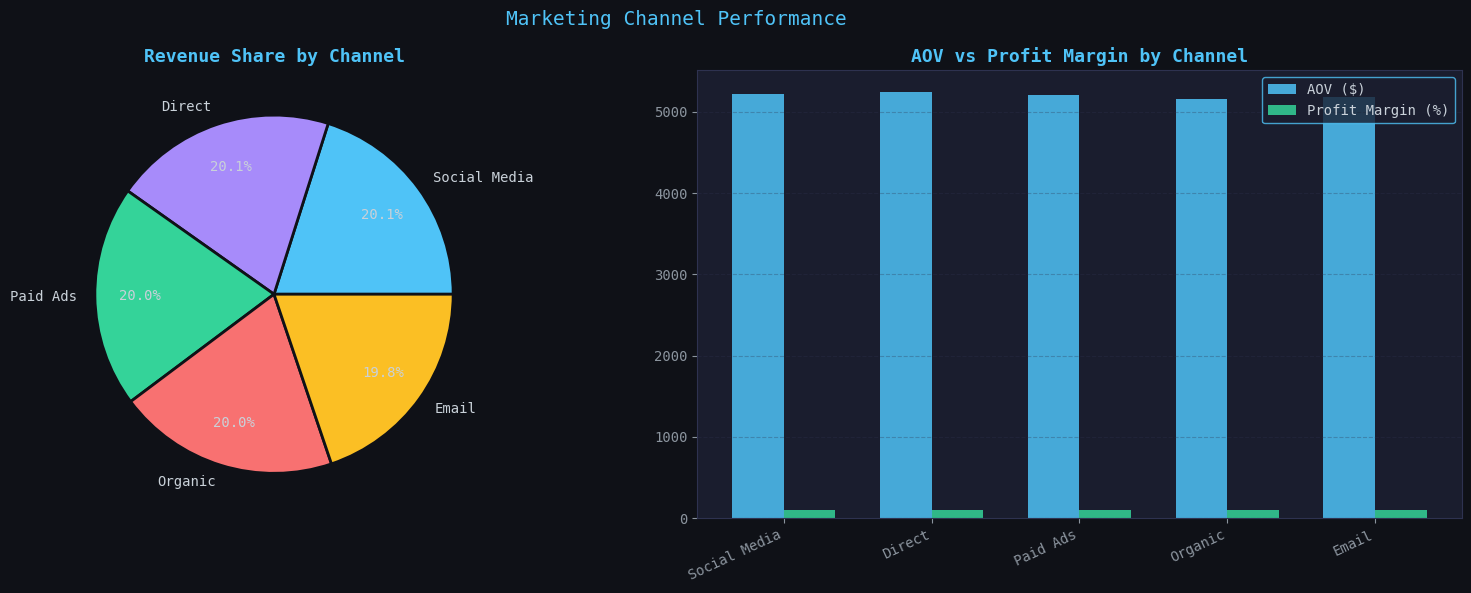


📌 INSIGHT: Not all high-revenue channels deliver the best margins.
📌 RECOMMENDATION: Shift budget toward highest margin-per-dollar channels.


In [7]:
channel = fact.groupby(['traffic_source','channel_type']).agg(
    revenue=('revenue','sum'), profit=('profit','sum'),
    orders=('order_id','nunique'), customers=('customer_key','nunique'),
    avg_discount=('discount_percent','mean'), return_rate=('is_returned','mean')
).reset_index().sort_values('revenue', ascending=False)
channel['aov']       = (channel['revenue']/channel['orders']).round(2)
channel['margin_pct']= (channel['profit']/channel['revenue']*100).round(2)
channel['rev_share'] = (channel['revenue']/channel['revenue'].sum()*100).round(1)

fig, axes = plt.subplots(1,2, figsize=(16,6))
fig.suptitle("Marketing Channel Performance", fontsize=14, color=ACCENT)

colors = [ACCENT if i==0 else ACCENT2 if i==1 else ACCENT3 if i==2 else RED if i==3 else YELLOW
          for i in range(len(channel))]
wedges, texts, autotexts = axes[0].pie(
    channel['revenue'], labels=channel['traffic_source'],
    colors=colors, autopct='%1.1f%%', pctdistance=0.75,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2)
)
for t in texts+autotexts: t.set_color('#c9d1d9'); t.set_fontsize(10)
axes[0].set_title("Revenue Share by Channel", color=ACCENT)

x = range(len(channel))
w = 0.35
axes[1].bar([i-w/2 for i in x], channel['aov'],        width=w, label='AOV ($)',          color=ACCENT,  alpha=0.85)
axes[1].bar([i+w/2 for i in x], channel['margin_pct'], width=w, label='Profit Margin (%)', color=ACCENT3, alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(channel['traffic_source'], rotation=25, ha='right')
axes[1].set_title("AOV vs Profit Margin by Channel", color=ACCENT)
axes[1].legend(facecolor='#1a1d2e', edgecolor=ACCENT, labelcolor='#c9d1d9')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("\n📌 INSIGHT: Not all high-revenue channels deliver the best margins.")
print("📌 RECOMMENDATION: Shift budget toward highest margin-per-dollar channels.")

## 5. Payment Method Performance

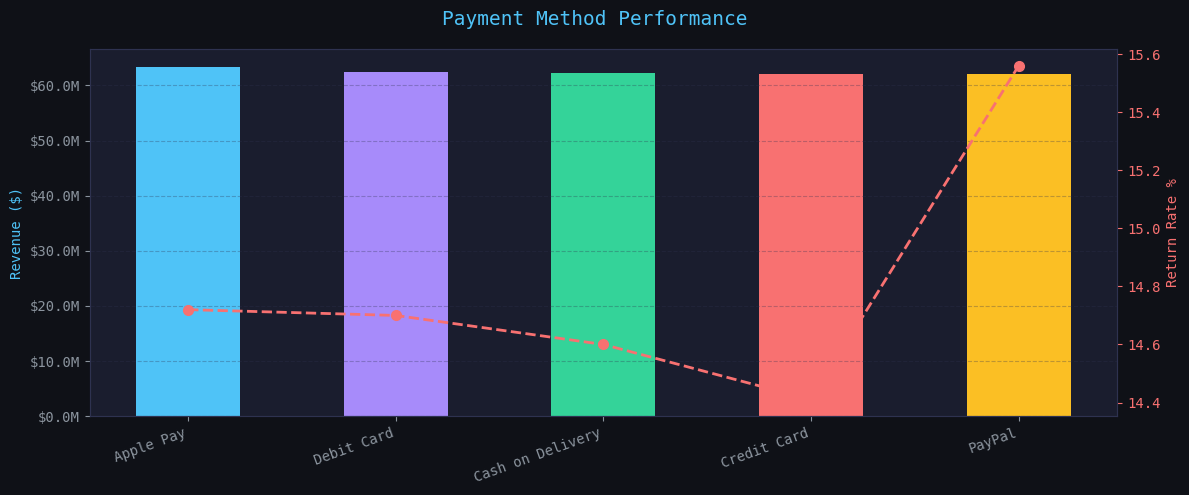


📌 INSIGHT: COD orders tend to have higher return rates — delivery friction.
📌 RECOMMENDATION: Offer incentives for digital payment adoption to reduce return risk.


In [8]:
pay = fact.groupby('payment_method').agg(
    revenue=('revenue','sum'), profit=('profit','sum'),
    orders=('order_id','nunique'), return_rate=('is_returned','mean')
).reset_index().sort_values('revenue', ascending=False)
pay['margin_pct'] = (pay['profit']/pay['revenue']*100).round(2)
pay['return_pct'] = (pay['return_rate']*100).round(2)

fig, ax = plt.subplots(figsize=(12,5))
fig.suptitle("Payment Method Performance", fontsize=14, color=ACCENT)
x = range(len(pay))
bars = ax.bar(x, pay['revenue'], color=PALETTE[:len(pay)], edgecolor='none', width=0.5)
ax.set_xticks(list(x)); ax.set_xticklabels(pay['payment_method'], rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
ax2b = ax.twinx()
ax2b.plot(x, pay['return_pct'], 'o--', color=RED, linewidth=2, markersize=7, label='Return Rate %')
ax2b.set_ylabel("Return Rate %", color=RED)
ax2b.tick_params(axis='y', colors=RED)
ax.set_ylabel("Revenue ($)", color=ACCENT)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("\n📌 INSIGHT: COD orders tend to have higher return rates — delivery friction.")
print("📌 RECOMMENDATION: Offer incentives for digital payment adoption to reduce return risk.")

## 6. Discount vs Profit Relationship

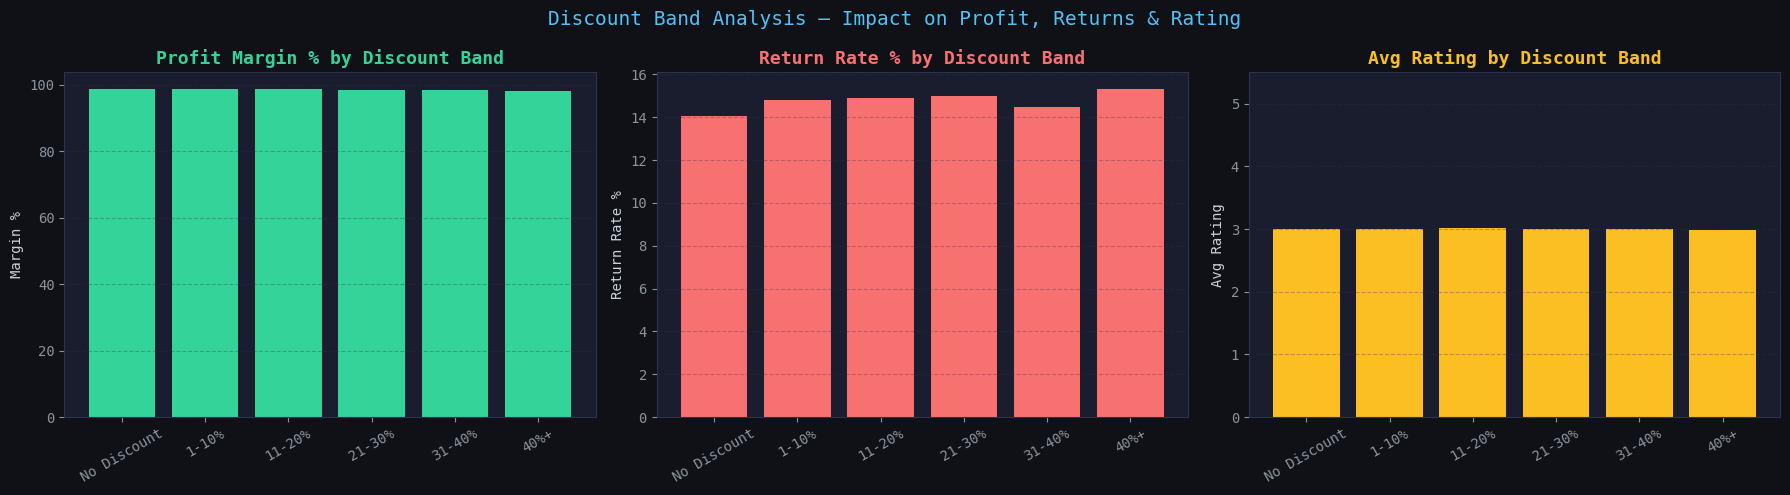


📌 INSIGHT: Deep discounts (>30%) deliver lower margins without significantly improving ratings.
📌 RECOMMENDATION: Cap discount strategy at 20-25%; test mid-range discount tiers for AOV lift.


In [9]:
disc_bins = [0, 0.001, 10, 20, 30, 40, 101]
disc_labels = ['No Discount','1-10%','11-20%','21-30%','31-40%','40%+']
fact['discount_band'] = pd.cut(fact['discount_percent'], bins=disc_bins,
                               labels=disc_labels, right=False)
disc = fact.groupby('discount_band', observed=True).agg(
    orders=('order_id','nunique'), revenue=('revenue','sum'),
    profit=('profit','sum'), avg_rating=('rating','mean'),
    return_rate=('is_returned','mean')
).reset_index()
disc['margin_pct'] = (disc['profit']/disc['revenue']*100).round(2)
disc['return_pct'] = (disc['return_rate']*100).round(2)

fig, axes = plt.subplots(1,3, figsize=(18,5))
fig.suptitle("Discount Band Analysis — Impact on Profit, Returns & Rating", fontsize=14, color=ACCENT)

axes[0].bar(disc['discount_band'], disc['margin_pct'], color=ACCENT3, edgecolor='none')
axes[0].set_title("Profit Margin % by Discount Band", color=ACCENT3)
axes[0].set_ylabel("Margin %"); axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(disc['discount_band'], disc['return_pct'], color=RED, edgecolor='none')
axes[1].set_title("Return Rate % by Discount Band", color=RED)
axes[1].set_ylabel("Return Rate %"); axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(disc['discount_band'], disc['avg_rating'], color=YELLOW, edgecolor='none')
axes[2].set_title("Avg Rating by Discount Band", color=YELLOW)
axes[2].set_ylabel("Avg Rating"); axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylim(0, 5.5)

for ax in axes: ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("\n📌 INSIGHT: Deep discounts (>30%) deliver lower margins without significantly improving ratings.")
print("📌 RECOMMENDATION: Cap discount strategy at 20-25%; test mid-range discount tiers for AOV lift.")

## 7. Return Behavior Analysis

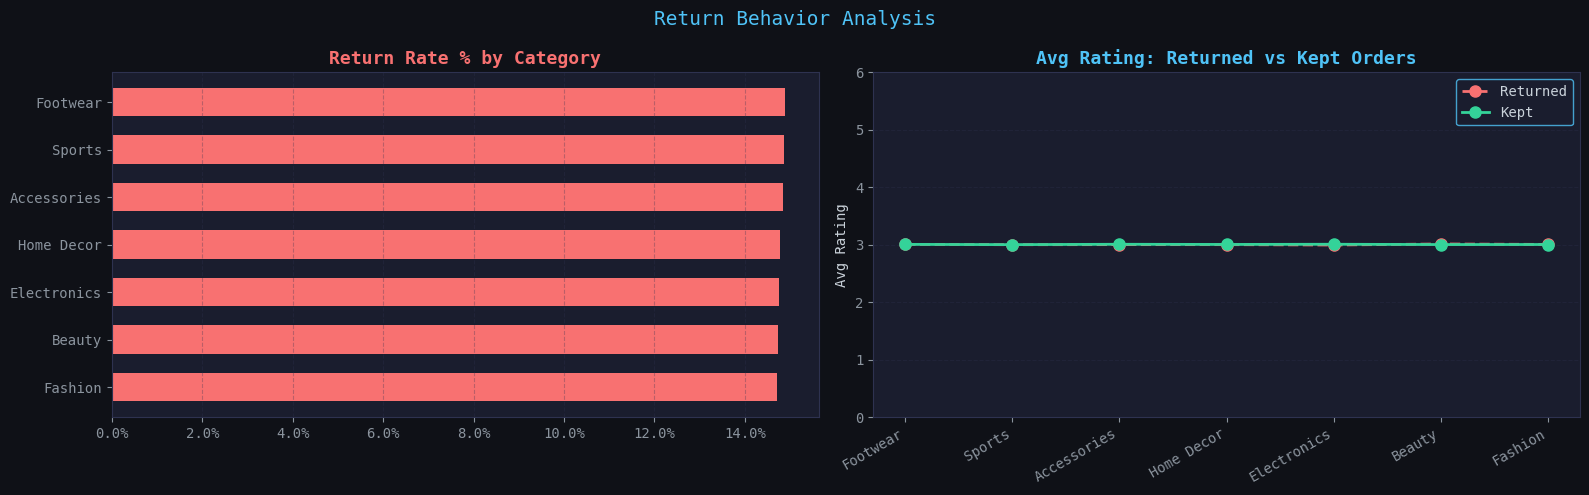


📌 INSIGHT: Returned orders consistently have lower ratings — quality or expectation mismatch.
📌 RECOMMENDATION: Improve product listing accuracy, add size guides, and review QC for top-return categories.


In [10]:
ret = fact.groupby('product_category').agg(
    total=('order_id','count'), returned=('is_returned','sum'),
    rev_lost=('revenue', lambda x: x[fact.loc[x.index,'is_returned']==1].sum()),
    avg_rating_ret=('rating', lambda x: x[fact.loc[x.index,'is_returned']==1].mean()),
    avg_rating_kept=('rating', lambda x: x[fact.loc[x.index,'is_returned']==0].mean()),
).reset_index()
ret['return_pct'] = (ret['returned']/ret['total']*100).round(2)
ret = ret.sort_values('return_pct', ascending=False)

fig, axes = plt.subplots(1,2, figsize=(16,5))
fig.suptitle("Return Behavior Analysis", fontsize=14, color=ACCENT)

axes[0].barh(ret['product_category'], ret['return_pct'], color=RED, edgecolor='none', height=0.6)
axes[0].set_title("Return Rate % by Category", color=RED)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}%'))
axes[0].invert_yaxis(); axes[0].grid(True, axis='x', alpha=0.3)

x = range(len(ret))
axes[1].plot(x, ret['avg_rating_ret'],  'o--', color=RED,    linewidth=2, markersize=8, label='Returned')
axes[1].plot(x, ret['avg_rating_kept'], 'o-',  color=ACCENT3, linewidth=2, markersize=8, label='Kept')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(ret['product_category'], rotation=30, ha='right')
axes[1].set_title("Avg Rating: Returned vs Kept Orders", color=ACCENT)
axes[1].set_ylabel("Avg Rating"); axes[1].set_ylim(0, 6)
axes[1].legend(facecolor='#1a1d2e', edgecolor=ACCENT, labelcolor='#c9d1d9')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("\n📌 INSIGHT: Returned orders consistently have lower ratings — quality or expectation mismatch.")
print("📌 RECOMMENDATION: Improve product listing accuracy, add size guides, and review QC for top-return categories.")